In [93]:
import pandas as pd
from sklearn . linear_model import Ridge
from sklearn . preprocessing import PolynomialFeatures , StandardScaler
from sklearn . metrics import mean_squared_error
import numpy as np
import matplotlib . pyplot as plt
from sklearn . linear_model import LinearRegression

In [94]:
train_df = pd.read_csv('energyefficient_train.csv')
test_df = pd.read_csv("energyefficient_test.csv")
val_df = pd.read_csv("energyefficient_val.csv")

In [95]:
feature_cols = ['X1' , 'X2' , 'X3' , 'X4' , 'X5' , 'X6' , 'X7' , 'X8' , 'X9']

X_train_all = train_df[feature_cols].values
y_train = train_df ["Y"].values

X_val_all = val_df[feature_cols].values
y_val = val_df ["Y"].values

X_test_all = test_df[feature_cols]
y_test = test_df ["Y"].values

In [96]:

degrees = [1,2,3,4,5,6]
poly_all_result=[]
best_degree_all=None
best_val_rmse_poly_all = np.inf
best_model_poly_all = None
best_poly_all = None
train_rmses = []
val_rmses = []



for deg in degrees:
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train_all)
    X_val_poly = poly.transform(X_val_all)
    X_test_poly = poly.transform(X_test_all)
    

    # Train model
    model = Ridge(alpha = 1e-6)
    model.fit(X_train_poly, y_train)

    # Predict and calculate RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train_poly)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val_poly)))
    

    poly_all_result.append({'Degree':deg , 'Train_RMSE' : train_rmse , 'Val_RMSE' : val_rmse})

    if val_rmse < best_val_rmse_poly_all :
        best_val_rmse_poly_all = val_rmse
        best_degree_all = deg
        best_model_poly_all=model
        best_poly_all = poly

    print(f'Degree {deg} :  Train_RMSE : {train_rmse :.4f} |  Val_RMSE : {val_rmse : .4f} ')

X_test_best=best_poly_all.transform(X_test_all)
y_test_pred_poly_all = best_model_poly_all.predict(X_test_best)
rmse_test_poly_all = np.sqrt(mean_squared_error(y_test, y_test_pred_poly_all))
    
    
print(f' \n best degree = {best_degree_all}')
print(f'Test rmse = {rmse_test_poly_all : .4f}')

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Degree 1 :  Train_RMSE : 1.6700 |  Val_RMSE :  2.1211 
Degree 2 :  Train_RMSE : 0.6354 |  Val_RMSE :  0.7302 
Degree 3 :  Train_RMSE : 0.3037 |  Val_RMSE :  0.5124 
Degree 4 :  Train_RMSE : 0.5885 |  Val_RMSE :  0.8114 


/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


Degree 5 :  Train_RMSE : 1.2545 |  Val_RMSE :  1.3377 
Degree 6 :  Train_RMSE : 2.3750 |  Val_RMSE :  2.8629 
 
 best degree = 3
Test rmse =  0.5070


/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


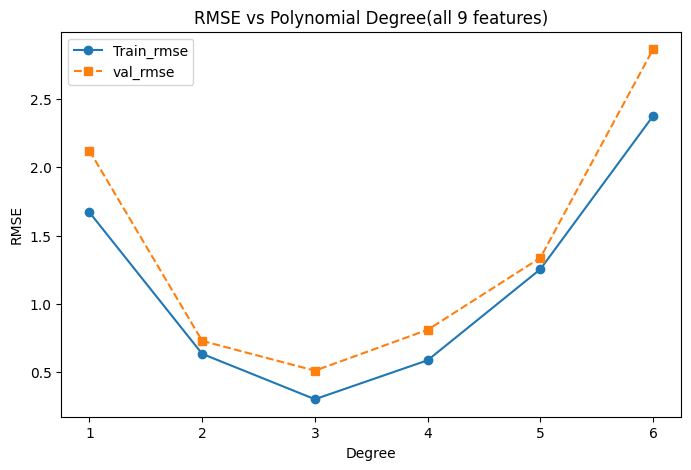

In [97]:
res_df = pd.DataFrame(poly_all_result)

plt.figure(figsize=(8, 5))
plt.plot(res_df['Degree'] , res_df['Train_RMSE'] ,'o-' , label= 'Train_rmse')
plt.plot(res_df['Degree'] , res_df['Val_RMSE'] ,'s--' , label= 'val_rmse')
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.legend()
plt.title("RMSE vs Polynomial Degree(all 9 features)")
plt.legend()
plt.show()

/tmp/ipykernel_427647/1125914843.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([mn,mx] , [mn,mx], 'r--' ,label = 'ideal fit' , color = 'Red')


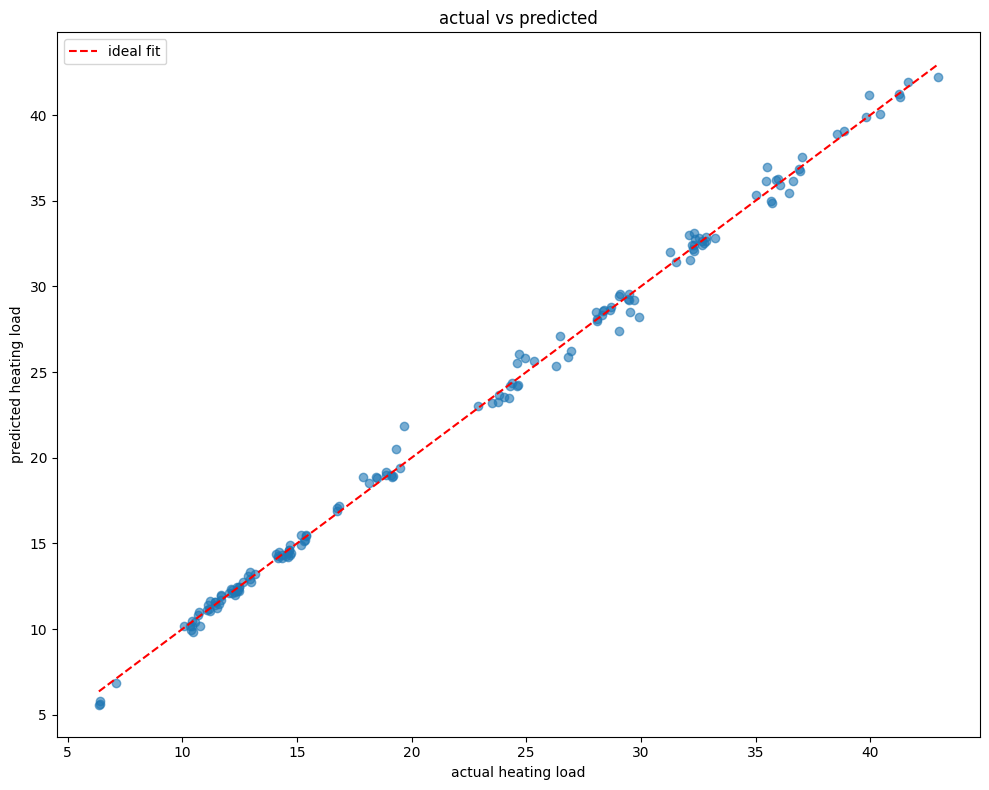

In [98]:
plt.figure(figsize=(10,8))
plt.scatter(y_test , y_test_pred_poly_all , alpha=0.6)
mn , mx = y_test.min() , y_test.max()
plt.plot([mn,mx] , [mn,mx], 'r--' ,label = 'ideal fit' , color = 'Red')
plt.xlabel ("actual heating load")
plt.ylabel('predicted heating load')
plt.title('actual vs predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
#ridge regression

In [100]:
deg6 = 6
alpha = 0.01

poly6 = PolynomialFeatures ( degree = deg6)
X_train6 = poly6 . fit_transform ( X_train_all )
X_val6 = poly6 . transform ( X_val_all )
X_test6 = poly6 . transform ( X_test_all )

lin6 = Ridge(alpha=1e-9)
lin6.fit(X_train6, y_train)
rmse_tr_lin6 = np.sqrt(mean_squared_error(y_train, lin6.predict(X_train6)))
rmse_vl_lin6 = np.sqrt(mean_squared_error(y_val,   lin6.predict(X_val6)))
rmse_te_lin6 = np.sqrt(mean_squared_error(y_test,  lin6.predict(X_test6)))





ridge6 = Ridge ( alpha = alpha)
ridge6.fit( X_train6 , y_train )

train_rmse6 = np.sqrt(mean_squared_error(y_train, ridge6.predict(X_train6)))
val_rmse6 = np.sqrt(mean_squared_error(y_val, ridge6.predict(X_val6)))
test_rmse6 = np.sqrt(mean_squared_error(y_test, ridge6.predict(X_test6)))

_pred_ridgre= ridge6.predict(X_test6)

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


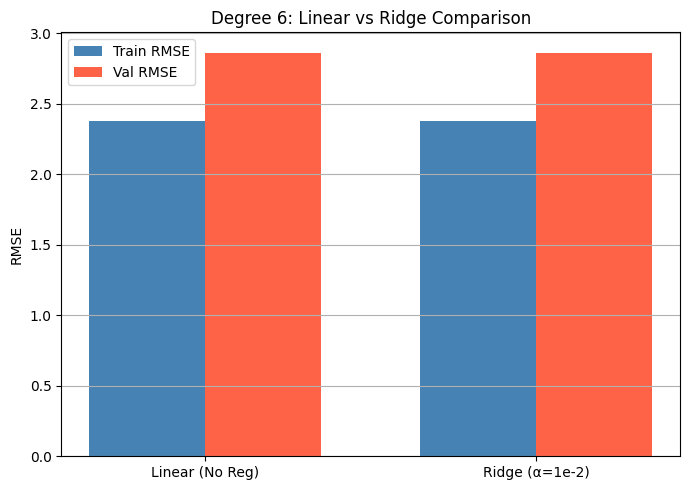

In [101]:
labels = ['Linear (No Reg)', f'Ridge (α=1e-2)']
train_vals = [rmse_tr_lin6, train_rmse6]
val_vals   = [rmse_vl_lin6, val_rmse6]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, train_vals, width, label='Train RMSE', color='steelblue')
ax.bar(x + width/2, val_vals,   width, label='Val RMSE',   color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('RMSE')
ax.set_title('Degree 6: Linear vs Ridge Comparison')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

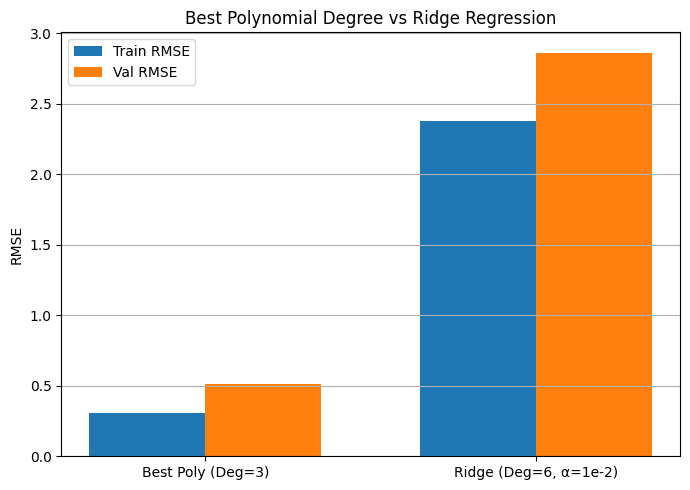

In [102]:
best_row = next(r for r in poly_all_result if r['Degree'] == best_degree_all)
labels2     = [f'Best Poly (Deg={best_degree_all})', 'Ridge (Deg=6, α=1e-2)']
train_vals2 = [best_row['Train_RMSE'], train_rmse6]
val_vals2   = [best_row['Val_RMSE'],   val_rmse6]
x2 = np.arange(len(labels2))
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x2 - width/2, train_vals2, width, label='Train RMSE')
ax.bar(x2 + width/2, val_vals2,   width, label='Val RMSE')
ax.set_xticks(x2)
ax.set_xticklabels(labels2)
ax.set_ylabel('RMSE')
ax.set_title('Best Polynomial Degree vs Ridge Regression')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

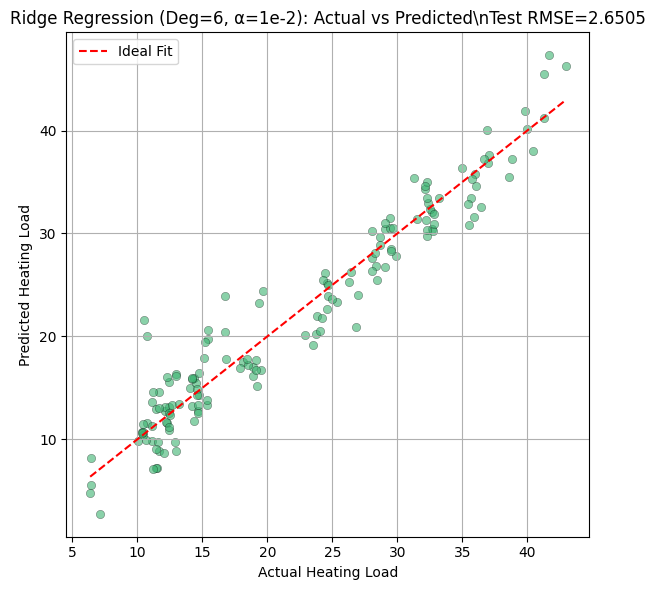

In [103]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, _pred_ridgre , alpha=0.6, color='mediumseagreen', edgecolors='k', linewidths=0.3)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Ideal Fit')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'Ridge Regression (Deg=6, α=1e-2): Actual vs Predicted\\nTest RMSE={test_rmse6:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
#neural network (9 features)

In [105]:
import torch
import torch.nn as nn
import torch.optim as optim

In [106]:
scaler_all = StandardScaler()
X_tr_nn_all = scaler_all.fit_transform(X_train_all)
X_vl_nn_all = scaler_all.transform(X_val_all)
X_te_nn_all = scaler_all.transform(X_test_all)
def to_tensor(X, y):
    return (torch.FloatTensor(X),
            torch.FloatTensor(y).reshape(-1, 1))
X_tr_t, y_tr_t = to_tensor(X_tr_nn_all, y_train)
X_vl_t, y_vl_t = to_tensor(X_vl_nn_all, y_val)
X_te_t, y_te_t = to_tensor(X_te_nn_all, y_test)
print('Tensors created.')

Tensors created.


/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [107]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Net, self).__init__()
        self.fc1  = nn.Linear(input_size, hidden_size)
        self.tanh = nn.Tanh()
        self.fc2  = nn.Linear(hidden_size, 1)
    def forward(self, x):
        x = self.tanh(self.fc1(x))
        return self.fc2(x)
hidden_sizes  = [4, 8, 16, 32, 64]
epochs        = 700
lr            = 0.01
input_size_all = 9
nn_all_results   = []
nn_all_histories = {}
best_vl_rmse_nn_all = np.inf
best_nn_all = None
best_h_all  = None
for h in hidden_sizes:
    torch.manual_seed(42)
    model = Net(input_size_all, h)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out  = model(X_tr_t)
        loss = criterion(out, y_tr_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl_t), y_vl_t).item()
        val_losses.append(val_loss)
    nn_all_histories[h] = (train_losses, val_losses)
    model.eval()
    with torch.no_grad():
        rmse_tr_nn = np.sqrt(criterion(model(X_tr_t), y_tr_t).item())
        rmse_vl_nn = np.sqrt(criterion(model(X_vl_t), y_vl_t).item())
    nn_all_results.append({'Hidden': h, 'Train RMSE': rmse_tr_nn, 'Val RMSE': rmse_vl_nn})
    if rmse_vl_nn < best_vl_rmse_nn_all:
        best_vl_rmse_nn_all = rmse_vl_nn
        best_nn_all = model
        best_h_all  = h
    print(f'Hidden={h:3d}: Train RMSE={rmse_tr_nn:.4f} | Val RMSE={rmse_vl_nn:.4f}')
best_nn_all.eval()
with torch.no_grad():
    y_test_pred_nn_all = best_nn_all(X_te_t).numpy().flatten()
rmse_test_nn_all = np.sqrt(mean_squared_error(y_test, y_test_pred_nn_all))
print(f'\\nBest hidden neurons = {best_h_all}')
print(f'Test RMSE           = {rmse_test_nn_all:.4f}')

Hidden=  4: Train RMSE=1.4078 | Val RMSE=1.9655
Hidden=  8: Train RMSE=1.3177 | Val RMSE=1.6817
Hidden= 16: Train RMSE=1.1455 | Val RMSE=1.5607
Hidden= 32: Train RMSE=1.2151 | Val RMSE=1.7263
Hidden= 64: Train RMSE=1.3221 | Val RMSE=1.8169
\nBest hidden neurons = 16
Test RMSE           = 1.3010


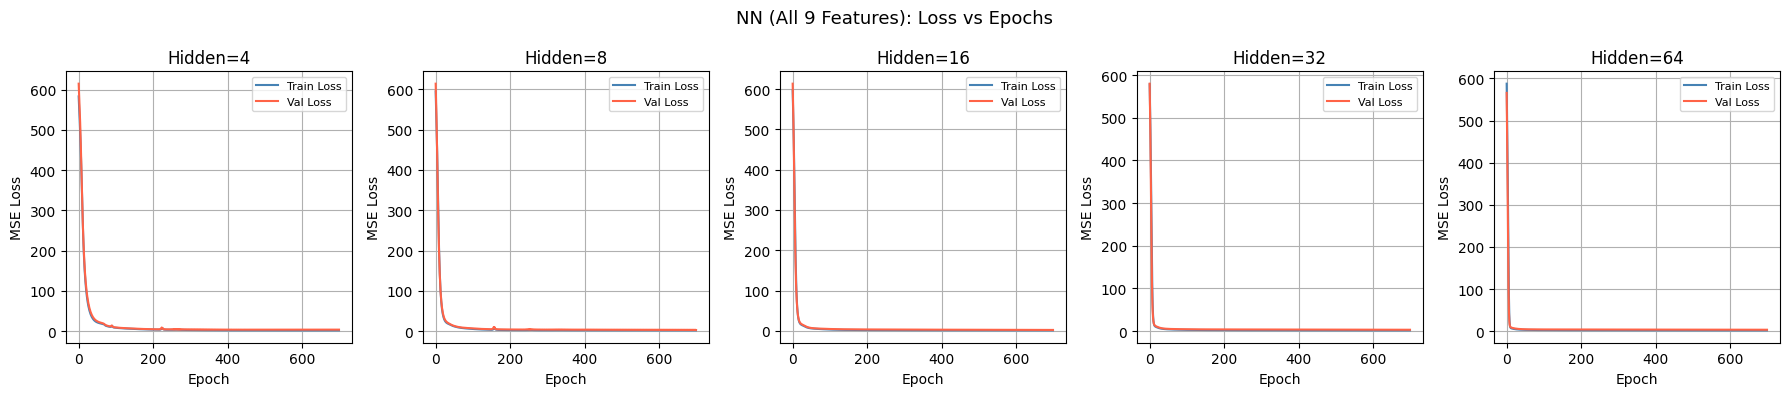

In [108]:
# Plot: Training and Validation Loss vs Epochs for all architectures (All 9 Features)
fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(18, 4), sharey=False)
for i, h in enumerate(hidden_sizes):
    tr_loss, vl_loss = nn_all_histories[h]
    axes[i].plot(tr_loss, label='Train Loss', color='steelblue')
    axes[i].plot(vl_loss, label='Val Loss',   color='tomato')
    axes[i].set_title(f'Hidden={h}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(True)
fig.suptitle('NN (All 9 Features): Loss vs Epochs', fontsize=13)
plt.tight_layout()
plt.show()

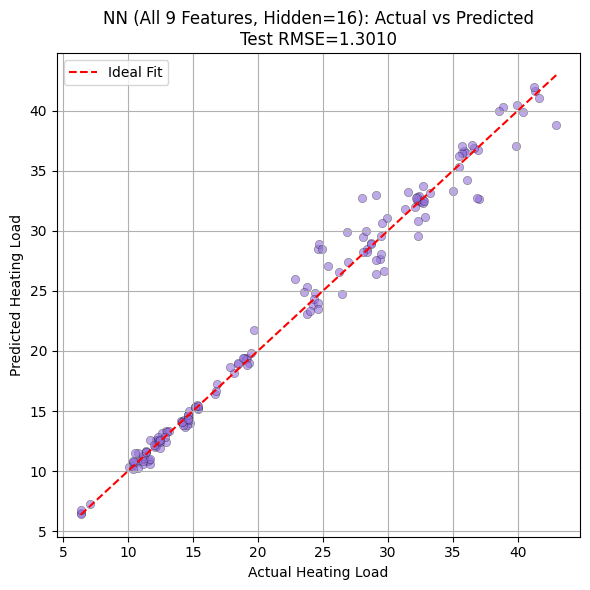

In [109]:
# Scatter Plot: Actual vs Predicted (Best NN, All 9 Features)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_nn_all, alpha=0.6, color='mediumpurple', edgecolors='k', linewidths=0.3)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Ideal Fit')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'NN (All 9 Features, Hidden={best_h_all}): Actual vs Predicted\nTest RMSE={rmse_test_nn_all:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [110]:
#non linear regression

Correlation with Heating Load (absolute value):
X9    0.976714
X5    0.886360
X4    0.858910
X2    0.650391
X1    0.611577
X3    0.471827
X7    0.274622
X8    0.079217
X6    0.004023
Name: Y, dtype: float64

Top-2 Features: ['X9', 'X5']


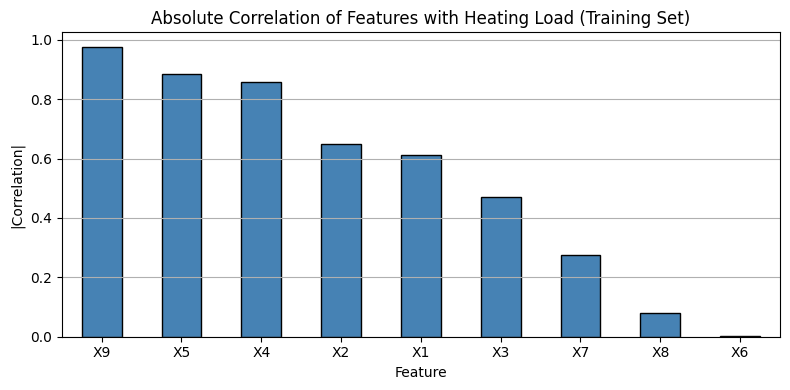

In [111]:
# Compute correlations on training set
correlations = train_df[feature_cols + ['Y']].corr()['Y'].drop('Y')
correlations_abs = correlations.abs().sort_values(ascending=False)

print('Correlation with Heating Load (absolute value):')
print(correlations_abs)

# Select top-2 features
top2_features = correlations_abs.index[:2].tolist()
print(f'\nTop-2 Features: {top2_features}')

# Plot correlation bar chart
plt.figure(figsize=(8, 4))
correlations_abs.plot(kind='bar', color='steelblue', edgecolor='k')
plt.title('Absolute Correlation of Features with Heating Load (Training Set)')
plt.ylabel('|Correlation|')
plt.xlabel('Feature')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('correlation_bar.png', dpi=150)
plt.show()

In [112]:
# Prepare top-2 feature datasets
X_train_t2 = train_df[top2_features].values
X_val_t2   = val_df[top2_features].values
X_test_t2  = test_df[top2_features].values

f1, f2 = top2_features
print(f'Feature 1: {f1}, Feature 2: {f2}')

Feature 1: X9, Feature 2: X5


In [113]:
poly_t2_results = []
best_val_rmse_poly_t2 = np.inf
best_degree_t2 = None
best_model_poly_t2 = None
best_poly_t2 = None

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=True)
    X_tr_p = poly.fit_transform(X_train_t2)
    X_vl_p = poly.transform(X_val_t2)
    X_te_p = poly.transform(X_test_t2)
    
    model = Ridge(alpha=1e-6)
    model.fit(X_tr_p, y_train)
    
    rmse_tr = np.sqrt(mean_squared_error(y_train, model.predict(X_tr_p)))
    rmse_vl = np.sqrt(mean_squared_error(y_val,   model.predict(X_vl_p)))
    
    poly_t2_results.append({'Degree': deg, 'Train RMSE': rmse_tr, 'Val RMSE': rmse_vl})
    
    if rmse_vl < best_val_rmse_poly_t2:
        best_val_rmse_poly_t2 = rmse_vl
        best_degree_t2 = deg
        best_model_poly_t2 = model
        best_poly_t2 = poly
    
    print(f'Degree {deg}: Train RMSE = {rmse_tr:.4f} | Val RMSE = {rmse_vl:.4f}')

X_te_best_t2 = best_poly_t2.transform(X_test_t2)
y_test_pred_poly_t2 = best_model_poly_t2.predict(X_te_best_t2)
rmse_test_poly_t2 = np.sqrt(mean_squared_error(y_test, y_test_pred_poly_t2))
print(f'\nBest Degree = {best_degree_t2}')
print(f'Test RMSE   = {rmse_test_poly_t2:.4f}')

Degree 1: Train RMSE = 2.1239 | Val RMSE = 2.3551
Degree 2: Train RMSE = 2.0129 | Val RMSE = 2.1758
Degree 3: Train RMSE = 1.9948 | Val RMSE = 2.1433
Degree 4: Train RMSE = 1.9703 | Val RMSE = 2.1377
Degree 5: Train RMSE = 1.9145 | Val RMSE = 2.1039
Degree 6: Train RMSE = 1.9071 | Val RMSE = 2.0983

Best Degree = 6
Test RMSE   = 1.9956


/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.78711e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.41291e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.78711e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/user/.local/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.41291e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


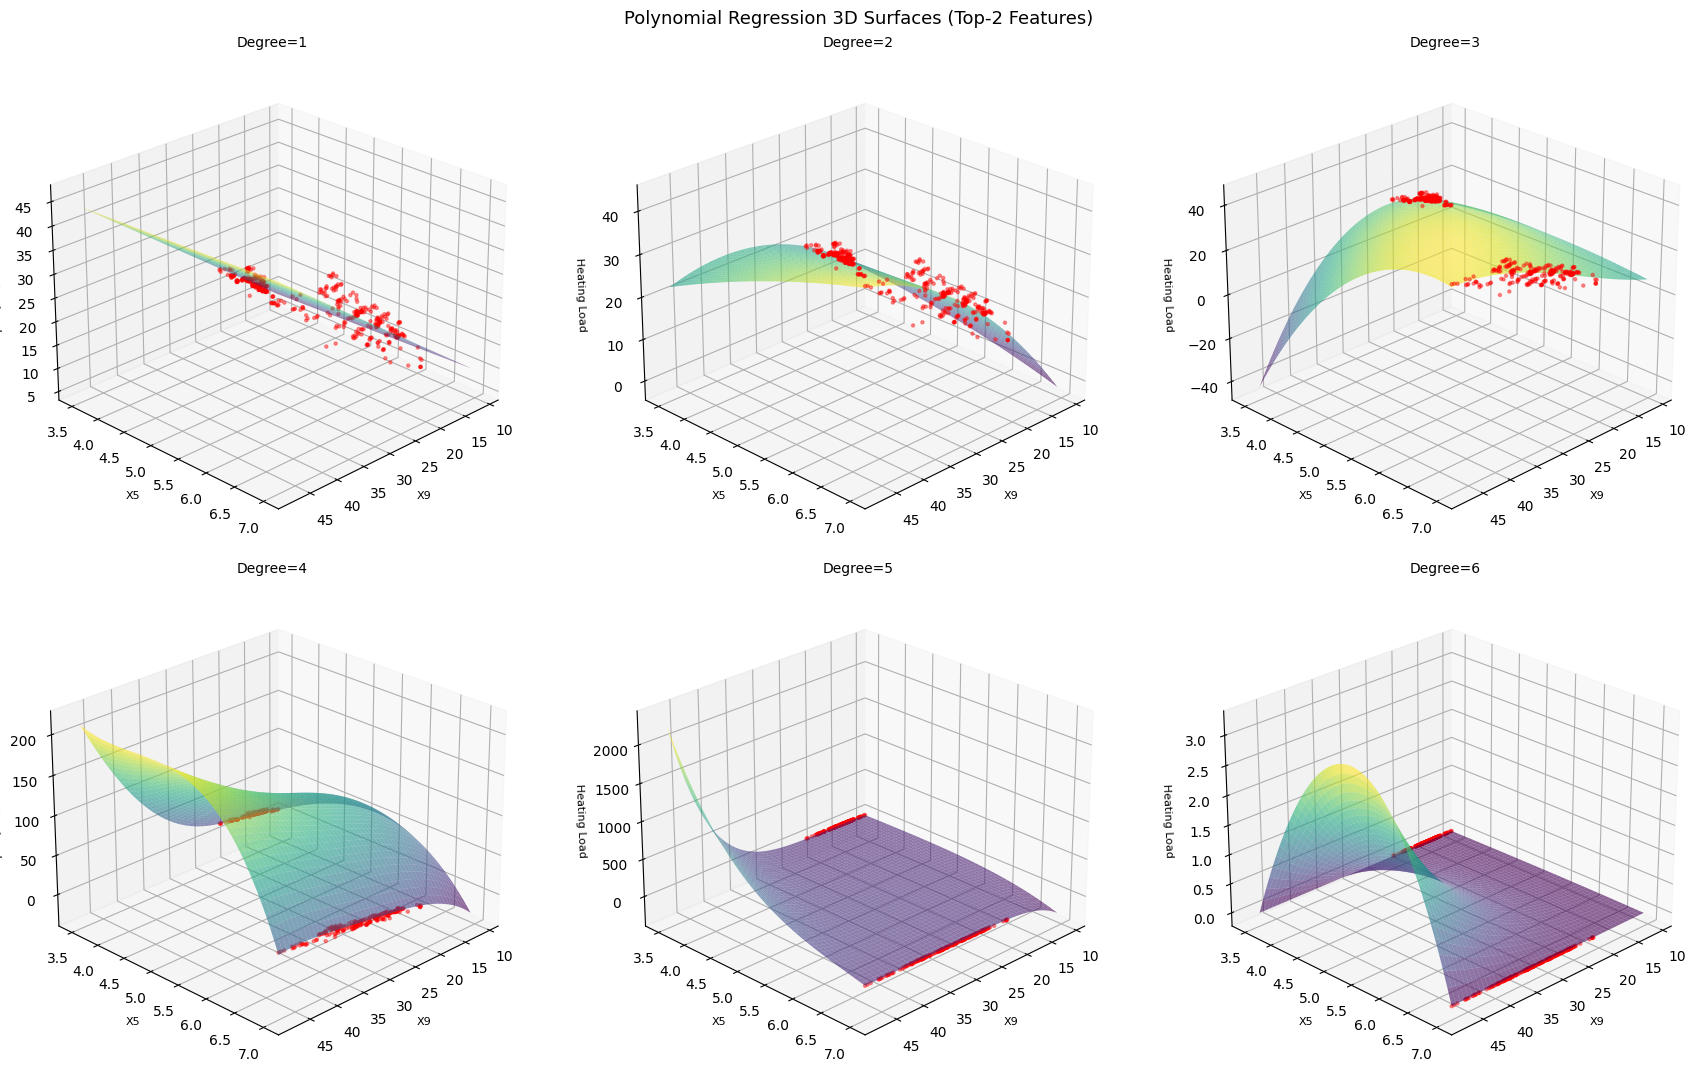

In [114]:
# 3D Best-Fit Surface for each polynomial degree (Top-2 Features)
n_grid = 50

fig_cols = 3
fig_rows = 2
fig3d = plt.figure(figsize=(18, 11))

for idx, deg in enumerate(degrees):
    poly = PolynomialFeatures(degree=deg, include_bias=True)
    X_tr_p = poly.fit_transform(X_train_t2)
    model  = Ridge(alpha=1e-6)
    model.fit(X_tr_p, y_train)
    
    ax = fig3d.add_subplot(fig_rows, fig_cols, idx+1, projection='3d')
    
    x1_lin = np.linspace(X_train_t2[:, 0].min(), X_train_t2[:, 0].max(), n_grid)
    x2_lin = np.linspace(X_train_t2[:, 1].min(), X_train_t2[:, 1].max(), n_grid)
    X1g, X2g = np.meshgrid(x1_lin, x2_lin)
    grid_pts = np.c_[X1g.ravel(), X2g.ravel()]
    Z_pred   = model.predict(poly.transform(grid_pts)).reshape(X1g.shape)
    
    ax.plot_surface(X1g, X2g, Z_pred, cmap='viridis', alpha=0.6)
    ax.scatter(X_train_t2[:, 0], X_train_t2[:, 1], y_train, color='red', s=5, alpha=0.4)
    ax.set_xlabel(f1, fontsize=8)
    ax.set_ylabel(f2, fontsize=8)
    ax.set_zlabel('Heating Load', fontsize=8)
    ax.set_title(f'Degree={deg}', fontsize=10)
    ax.view_init(elev=25, azim=45)

fig3d.suptitle('Polynomial Regression 3D Surfaces (Top-2 Features)', fontsize=13)
plt.tight_layout()
plt.show()

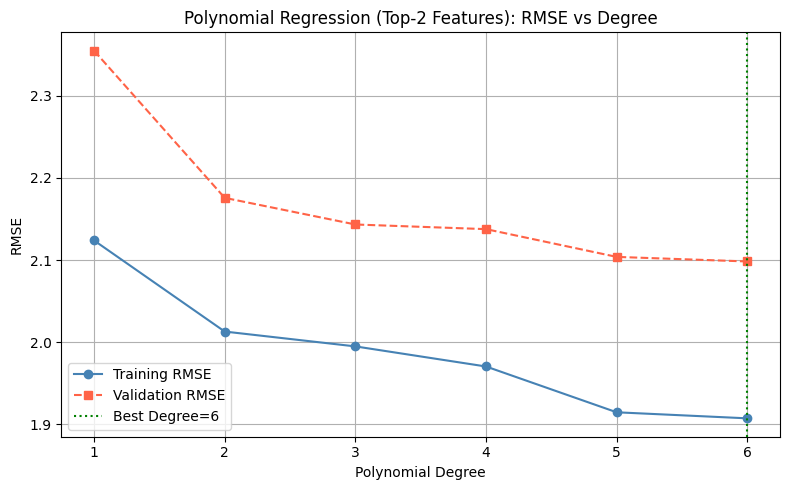

In [115]:
# Line Graph: Train/Val RMSE vs Degree (Top-2)
res_t2 = pd.DataFrame(poly_t2_results)

plt.figure(figsize=(8, 5))
plt.plot(res_t2['Degree'], res_t2['Train RMSE'], 'o-', label='Training RMSE', color='steelblue')
plt.plot(res_t2['Degree'], res_t2['Val RMSE'],   's--', label='Validation RMSE', color='tomato')
plt.axvline(best_degree_t2, color='green', linestyle=':', label=f'Best Degree={best_degree_t2}')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Polynomial Regression (Top-2 Features): RMSE vs Degree')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

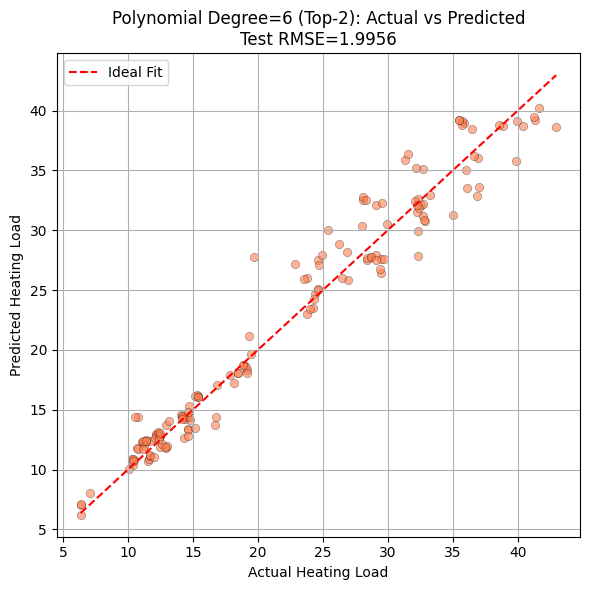

In [116]:
# Scatter Plot: Actual vs Predicted (Best Degree, Top-2)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_poly_t2, alpha=0.6, color='coral', edgecolors='k', linewidths=0.3)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Ideal Fit')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'Polynomial Degree={best_degree_t2} (Top-2): Actual vs Predicted\nTest RMSE={rmse_test_poly_t2:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [117]:
#NEURALETWORK TOP 2

In [118]:
# Normalize top-2 features
scaler_t2 = StandardScaler()
X_tr_nn_t2 = scaler_t2.fit_transform(X_train_t2)
X_vl_nn_t2 = scaler_t2.transform(X_val_t2)
X_te_nn_t2 = scaler_t2.transform(X_test_t2)

X_tr_t2_tens, y_tr_t2_tens = to_tensor(X_tr_nn_t2, y_train)
X_vl_t2_tens, y_vl_t2_tens = to_tensor(X_vl_nn_t2, y_val)
X_te_t2_tens, y_te_t2_tens = to_tensor(X_te_nn_t2, y_test)

nn_t2_results   = []
nn_t2_histories = {}

best_vl_rmse_nn_t2 = np.inf
best_nn_t2 = None
best_h_t2  = None

for h in hidden_sizes:
    torch.manual_seed(42)
    model = Net(2, h)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out  = model(X_tr_t2_tens)
        loss = criterion(out, y_tr_t2_tens)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl_t2_tens), y_vl_t2_tens).item()
        val_losses.append(val_loss)
    
    nn_t2_histories[h] = (train_losses, val_losses)
    
    model.eval()
    with torch.no_grad():
        rmse_tr_nn = np.sqrt(criterion(model(X_tr_t2_tens), y_tr_t2_tens).item())
        rmse_vl_nn = np.sqrt(criterion(model(X_vl_t2_tens), y_vl_t2_tens).item())
    
    nn_t2_results.append({'Hidden': h, 'Train RMSE': rmse_tr_nn, 'Val RMSE': rmse_vl_nn})
    
    if rmse_vl_nn < best_vl_rmse_nn_t2:
        best_vl_rmse_nn_t2 = rmse_vl_nn
        best_nn_t2 = model
        best_h_t2  = h
    
    print(f'Hidden={h:3d}: Train RMSE={rmse_tr_nn:.4f} | Val RMSE={rmse_vl_nn:.4f}')

best_nn_t2.eval()
with torch.no_grad():
    y_test_pred_nn_t2 = best_nn_t2(X_te_t2_tens).numpy().flatten()
rmse_test_nn_t2 = np.sqrt(mean_squared_error(y_test, y_test_pred_nn_t2))
print(f'\nBest hidden neurons = {best_h_t2}')
print(f'Test RMSE           = {rmse_test_nn_t2:.4f}')

Hidden=  4: Train RMSE=2.0314 | Val RMSE=2.2149
Hidden=  8: Train RMSE=1.9568 | Val RMSE=2.1266
Hidden= 16: Train RMSE=2.0091 | Val RMSE=2.1658
Hidden= 32: Train RMSE=2.0110 | Val RMSE=2.1687
Hidden= 64: Train RMSE=2.0156 | Val RMSE=2.1751

Best hidden neurons = 8
Test RMSE           = 2.0244


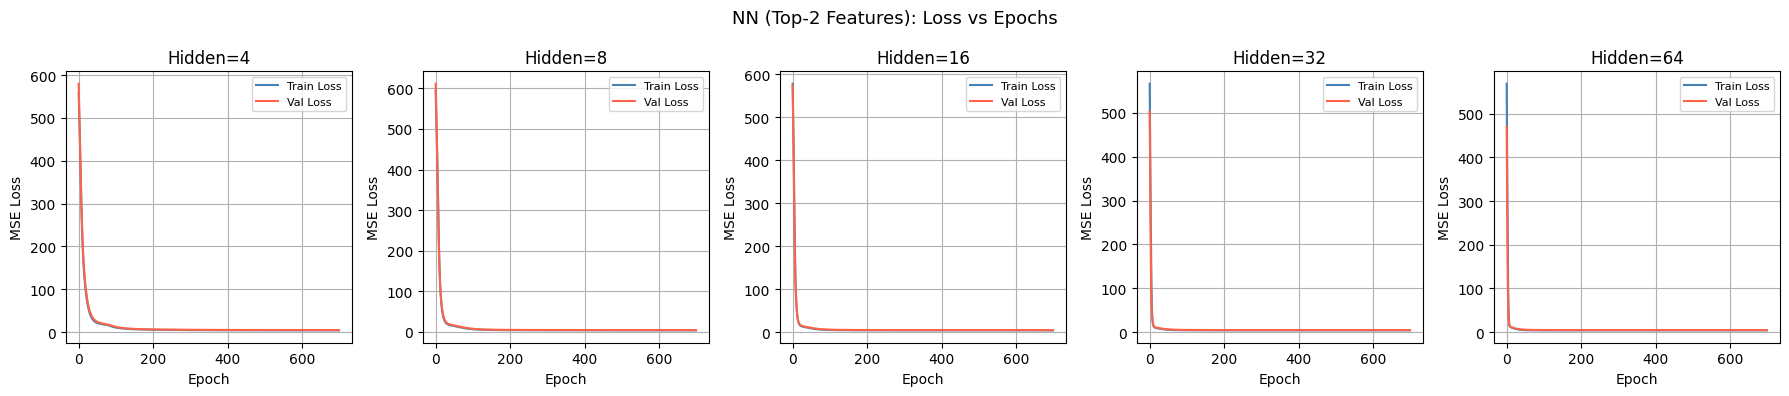

In [119]:
# Plot: Training and Validation Loss vs Epochs (Top-2 Features)
fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(18, 4), sharey=False)
for i, h in enumerate(hidden_sizes):
    tr_loss, vl_loss = nn_t2_histories[h]
    axes[i].plot(tr_loss, label='Train Loss', color='steelblue')
    axes[i].plot(vl_loss, label='Val Loss',   color='tomato')
    axes[i].set_title(f'Hidden={h}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(True)
fig.suptitle('NN (Top-2 Features): Loss vs Epochs', fontsize=13)
plt.tight_layout()
plt.show()

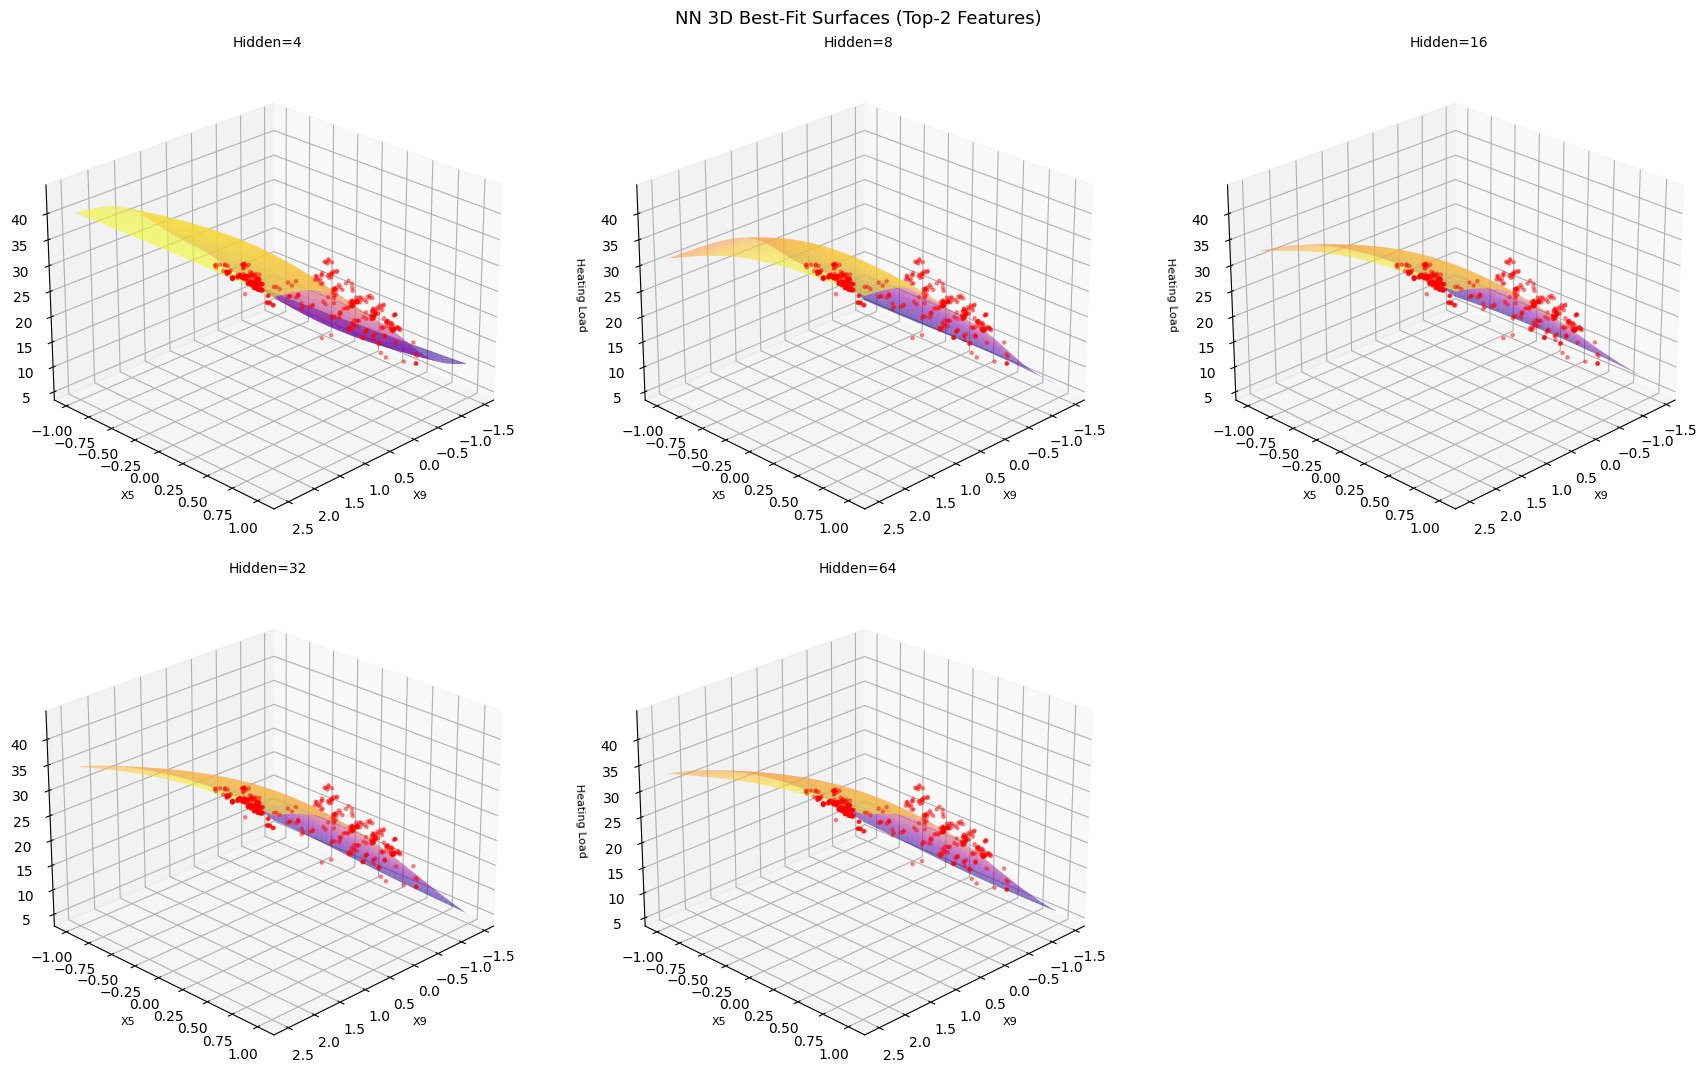

In [120]:
# 3D Best-Fit Surfaces for each NN architecture (Top-2 Features)
fig3d_nn = plt.figure(figsize=(18, 11))

for idx, h in enumerate(hidden_sizes):
    torch.manual_seed(42)
    model_h = Net(2, h)
    crit    = nn.MSELoss()
    opt     = optim.SGD(model_h.parameters(), lr=lr)
    
    for _ in range(epochs):
        model_h.train()
        opt.zero_grad()
        loss_h = crit(model_h(X_tr_t2_tens), y_tr_t2_tens)
        loss_h.backward()
        opt.step()
    
    ax = fig3d_nn.add_subplot(2, 3, idx+1, projection='3d')
    
    x1_lin = np.linspace(X_tr_nn_t2[:, 0].min(), X_tr_nn_t2[:, 0].max(), 40)
    x2_lin = np.linspace(X_tr_nn_t2[:, 1].min(), X_tr_nn_t2[:, 1].max(), 40)
    X1g, X2g = np.meshgrid(x1_lin, x2_lin)
    grid_nn   = torch.FloatTensor(np.c_[X1g.ravel(), X2g.ravel()])
    
    model_h.eval()
    with torch.no_grad():
        Z_nn = model_h(grid_nn).numpy().reshape(X1g.shape)
    
    ax.plot_surface(X1g, X2g, Z_nn, cmap='plasma', alpha=0.6)
    ax.scatter(X_tr_nn_t2[:, 0], X_tr_nn_t2[:, 1], y_train, color='red', s=5, alpha=0.4)
    ax.set_xlabel(f1, fontsize=8)
    ax.set_ylabel(f2, fontsize=8)
    ax.set_zlabel('Heating Load', fontsize=8)
    ax.set_title(f'Hidden={h}', fontsize=10)
    ax.view_init(elev=25, azim=45)

fig3d_nn.suptitle('NN 3D Best-Fit Surfaces (Top-2 Features)', fontsize=13)
plt.tight_layout()
plt.show()

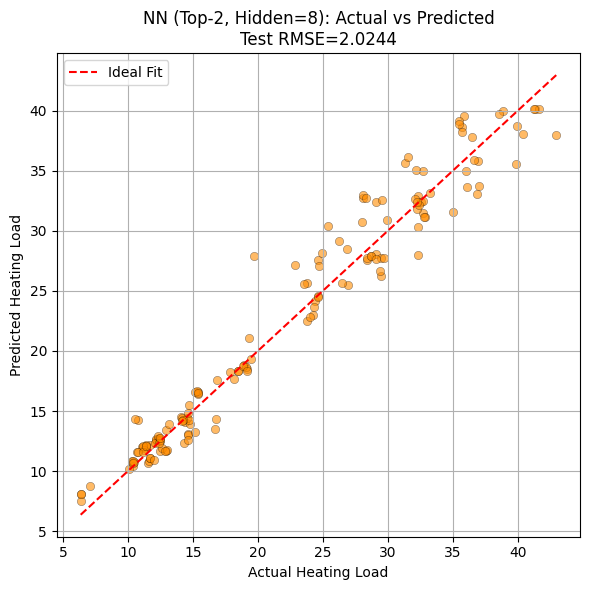

In [121]:
# Scatter Plot: Actual vs Predicted (Best NN, Top-2 Features)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_nn_t2, alpha=0.6, color='darkorange', edgecolors='k', linewidths=0.3)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Ideal Fit')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'NN (Top-2, Hidden={best_h_t2}): Actual vs Predicted\nTest RMSE={rmse_test_nn_t2:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [122]:
summary = {
    'Model': [
        f'Poly Reg (All 9, Best Deg={best_degree_all})',
        f'Ridge Reg (All 9, Deg=6, α=1e-2)',
        f'NN (All 9, Hidden={best_h_all})',
        f'Poly Reg (Top-2, Best Deg={best_degree_t2})',
        f'NN (Top-2, Hidden={best_h_t2})',
    ],
    'Test RMSE': [
        round(rmse_test_poly_all, 4),
        round(test_rmse6, 4),
        round(rmse_test_nn_all, 4),
        round(rmse_test_poly_t2, 4),
        round(rmse_test_nn_t2, 4),
    ]
}

summary_df = pd.DataFrame(summary)
print('=== Final Results Summary ===')
print(summary_df.to_string(index=False))

=== Final Results Summary ===
                           Model  Test RMSE
    Poly Reg (All 9, Best Deg=3)     0.5070
Ridge Reg (All 9, Deg=6, α=1e-2)     2.6505
           NN (All 9, Hidden=16)     1.3010
    Poly Reg (Top-2, Best Deg=6)     1.9956
            NN (Top-2, Hidden=8)     2.0244
